In [ ]:
"""
Author: eveie Prewitt
Exploritory data analysis for the Strait of Hormuz project.
This is a Jupyter notebook containing code for the visuals
used the the EDA section of the final project report.
This notebook is for analysis only and is not intended to be run as a script.
"""

In [1]:
import mapping

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
presence_90 = pd.read_csv('presence_hormuz_2026-04-30_2026-07-29.csv')
presence_peaceful = pd.read_csv('peacetime_hormuz_2022-01-01_2022-12-31.csv')
snap = pd.read_csv('snapshot_hormuz_20260803T050455Z.csv')
presence_90.head()

,date,flag,gear_type,hours,vessel_id,vessel_type,entry_timestamp,exit_timestamp,first_transmission_date,last_transmission_date,imo,mmsi,call_sign,dataset,report_dataset,ship_name,lat,lon
0,2026-07-17,MDG,CARGO,6.0,77813c143-3689-4e6d-1fd8-79db6f9694fe,CARGO,2026-05-05T05:00:00Z,2026-07-17T05:00:00Z,2026-02-06T09:59:57Z,2026-07-17T05:00:57Z,9273002.0,647553004.0,5RA04,public-global-vessel-identity:v4.0,public-global-presence:v4.0,STARBOUND EXPLORER,26.0,55.799999
1,2026-05-01,IRN,CARGO,1.0,67ab33f72-2f5f-9631-3ec0-ff0834deee88,CARGO,2026-04-30T03:00:00Z,2026-05-22T14:00:00Z,2017-11-06T08:00:21Z,2026-07-31T23:28:22Z,9795036.0,422085700.0,EPDZ2,public-global-vessel-identity:v4.0,public-global-presence:v4.0,NEZAMI GANJAVI 5,25.4,57.200001
2,2026-06-23,IRN,CARGO,1.0,471c6c376-6553-582f-6b03-502410126e90,CARGO,2026-04-30T11:00:00Z,2026-07-10T09:00:00Z,2012-10-16T17:42:33Z,2026-07-31T23:55:33Z,8508462.0,422141000.0,EQKF,public-global-vessel-identity:v4.0,public-global-presence:v4.0,BANEH,26.6,55.700001
3,2026-07-05,BES,CARGO,24.0,632a5c38c-c648-a7d2-c97a-a9d0ce6194a8,CARGO,2026-04-30T03:00:00Z,2026-07-11T18:00:00Z,2024-10-01T06:04:37Z,2026-07-31T23:56:21Z,9309239.0,306885000.0,8PJG6,public-global-vessel-identity:v4.0,public-global-presence:v4.0,OLGA,25.7,57.000000
4,2026-07-04,COM,CARGO,1.0,c175d823a-a4e4-382c-7e12-67284569fdef,CARGO,2026-06-11T09:00:00Z,2026-07-18T17:00:00Z,2024-01-30T11:50:52Z,2026-07-21T04:19:34Z,8936372.0,620999370.0,D6A3369,public-global-vessel-identity:v4.0,public-global-presence:v4.0,SHAHIN 2,25.6,55.400002


In [ ]:
# Contextualizing varible of interest in presence_90 dataset
presence_90['vessel_type'].value_counts()

vessel_type
CARGO      24168
BUNKER       768
CARRIER        4
Name: count, dtype: int64

In [ ]:
presence_90['hours'].describe()

count    24941.000000
mean         5.262058
std          7.022918
min          1.000000
25%          1.000000
50%          1.000000
75%          7.000000
max         24.000000
Name: hours, dtype: float64

In [38]:
presence_90['flag'].value_counts().head(10)

flag
IRN    8276
COM    3879
PAN    3317
MHL    1234
LBR    1209
KNA     980
HKG     476
SGP     413
IND     383
CMR     362
Name: count, dtype: int64

In [40]:
presence_peaceful['flag'].value_counts().head(3)

flag
IRN    73418
PAN    46351
LBR    29102
Name: count, dtype: int64

In [ ]:
presence_peaceful['vessel_type'].value_counts()

vessel_type
CARGO      275053
BUNKER       7812
CARRIER       528
Name: count, dtype: int64

In [41]:
snap['ship_type'].value_counts()

ship_type
Tanker    116
Name: count, dtype: int64

In [ ]:
snap['length_m'].describe()

count    110.000000
mean     162.327273
std       71.904512
min       40.000000
25%      105.500000
50%      148.500000
75%      210.500000
max      333.000000
Name: length_m, dtype: float64

In [43]:
snap['nav_status'].value_counts()

nav_status
At Anchor    6
Name: count, dtype: int64

In [5]:
# count how many flagless ships are present in the peacetime dataset
flagless_ships = presence_peaceful[presence_peaceful['flag'].isnull()].count()
print(f"Number of flagless ships in peacetime dataset:"
      f"{flagless_ships['vessel_id']}")
flagless_ships
(flagless_ships['vessel_id'] / presence_peaceful.size) * 100

NameError: name 'presence_peaceful' is not defined

In [19]:
# count the number of missing values in the presence_90 dataset
missing_values = presence_90.isnull().sum()
missing_values

date                          0
flag                          1
gear_type                     1
hours                         0
vessel_id                     0
vessel_type                   1
entry_timestamp               0
exit_timestamp                0
first_transmission_date       1
last_transmission_date        1
imo                        1946
mmsi                          1
call_sign                   106
dataset                       1
report_dataset                0
ship_name                    61
lat                           0
lon                           0
dtype: int64

In [26]:
# count the number of missing values in the snapshot dataset
snap_number_of_entries = snap.shape[0] * len(snap.columns)
print(f"Number of entries in snapshot dataset: {snap_number_of_entries}")
missing_values_snap = snap.isnull().sum()
missing_values_snap

Number of entries in snapshot dataset: 2436


observed_at                 0
ship_id                     0
shipname                    6
lat                         0
lon                         0
speed_knots                 1
course_deg                  8
heading_deg                22
rate_of_turn               38
minutes_since_position      0
destination                 8
flag                        6
length_m                    6
width_m                     6
dwt                         6
ship_type_code              0
ship_type                   0
detailed_type_code          6
nav_status                110
position_source             0
url                         6
dtype: int64

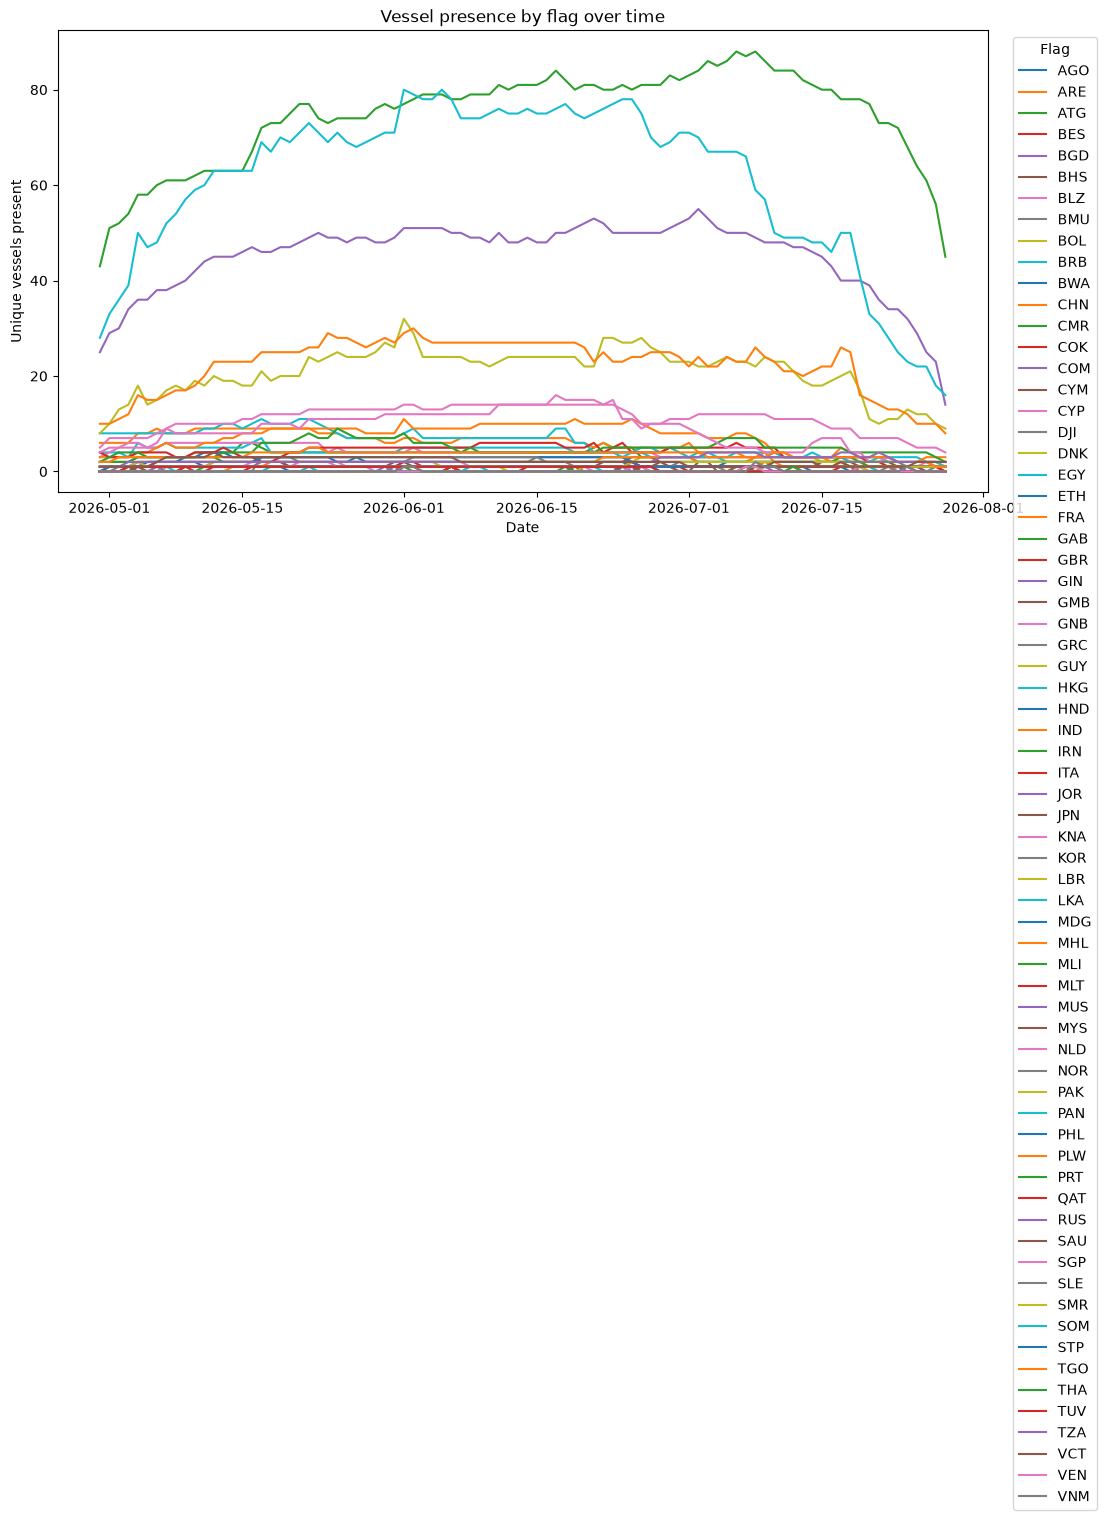

In [ ]:
# Create a DataFrame with one row per vessel per day of presence
rows = []
for _, row in presence_90.iterrows():
    active_days = pd.date_range(
        row["entry_timestamp"].floor("D"),
        row["exit_timestamp"].floor("D"),
        freq="D",
    )
    rows.append(
        pd.DataFrame({
            "date": active_days,
            "flag": row["flag"],
            "vessel_id": row["vessel_id"],
        })
    )

presence = pd.concat(rows, ignore_index=True)
presence = presence.drop_duplicates(["date", "flag", "vessel_id"])
counts = (
    presence.groupby(["date", "flag"])["vessel_id"]
            .nunique()
            .unstack(fill_value=0)
)

# Plot the counts of unique vessels by flag over time
plt.figure(figsize=(12, 6))
for flag in counts.columns:
    plt.plot(counts.index, counts[flag], label=flag)

plt.xlabel("Date")
plt.ylabel("Unique vessels present")
plt.title("Vessel presence by flag over time ")
plt.legend(title="Flag", bbox_to_anchor=(1.02, 1), loc="upper left")

In [47]:
counts.head()

flag,AGO,ARE,ATG,BES,BGD,BHS,BLZ,BMU,BOL,BRB,...,SMR,SOM,STP,TGO,THA,TUV,TZA,VCT,VEN,VNM
date,,,,,,,,,,,,,,,,,,,,,
2026-04-30 00:00:00+00:00,1,1,2,2,1,0,0,0,1,4,...,1,0,0,2,0,0,1,1,0,0
2026-05-01 00:00:00+00:00,1,1,2,2,1,0,0,0,1,4,...,1,0,1,2,0,0,1,1,0,0
2026-05-02 00:00:00+00:00,1,1,2,2,1,0,0,0,1,4,...,1,0,1,3,0,0,1,1,0,0
2026-05-03 00:00:00+00:00,1,1,2,2,1,0,0,0,1,3,...,1,0,1,3,0,1,2,1,0,0
2026-05-04 00:00:00+00:00,1,1,3,2,1,1,0,0,2,6,...,2,0,1,3,0,1,2,1,0,0


wrote presence_hormuz_2026-04-30_2026-07-29.png
wrote peacetime_hormuz_2022-01-01_2022-12-31.png


'peacetime_hormuz_2022-01-01_2022-12-31.png'

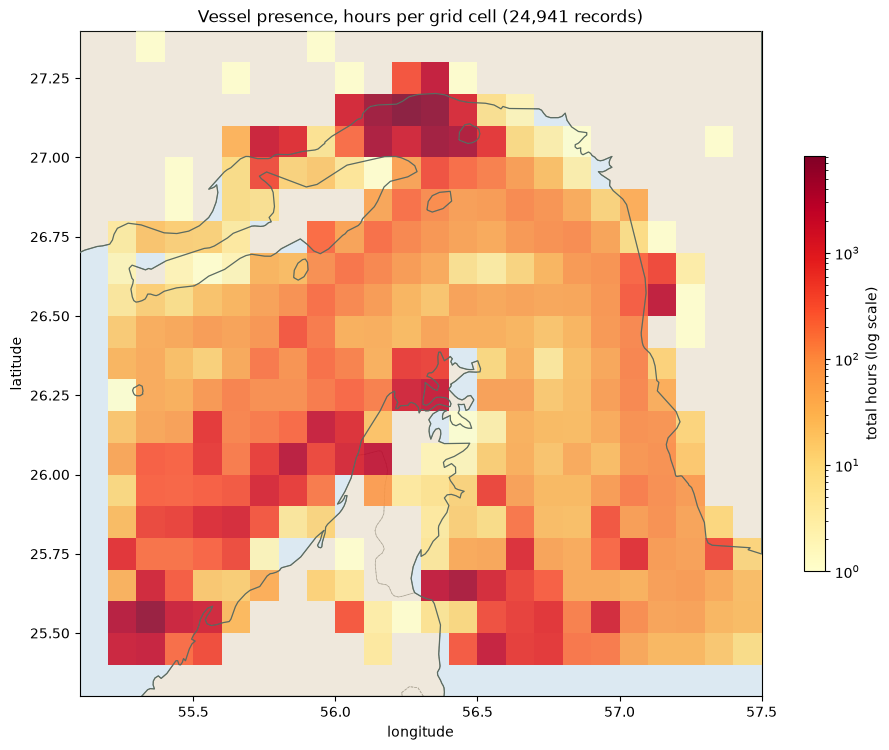

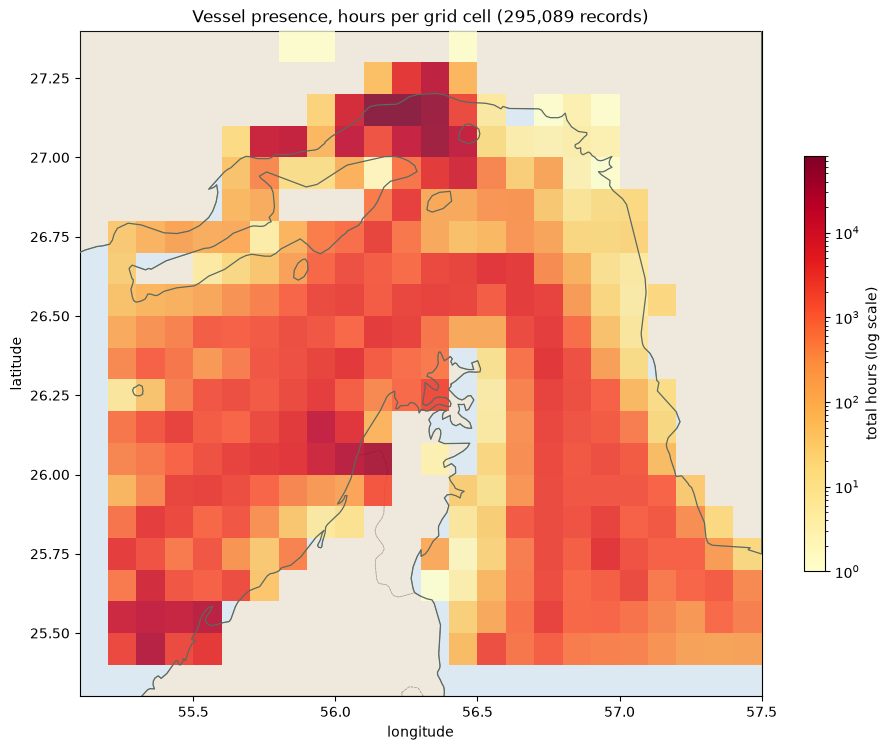

In [1]:
# Creates density maps for the presence_90 and peacetime datasets, and saves them as images. 
import mapping
mapping.draw('presence_hormuz_2026-04-30_2026-07-29.csv', region=mapping.regions.STRAIT_OF_HORMUZ, show=False)
mapping.draw('peacetime_hormuz_2022-01-01_2022-12-31.csv', region=mapping.regions.STRAIT_OF_HORMUZ, show=False)

wrote presence_hormuz_2026-04-30_2026-07-29_diff.png


'presence_hormuz_2026-04-30_2026-07-29_diff.png'

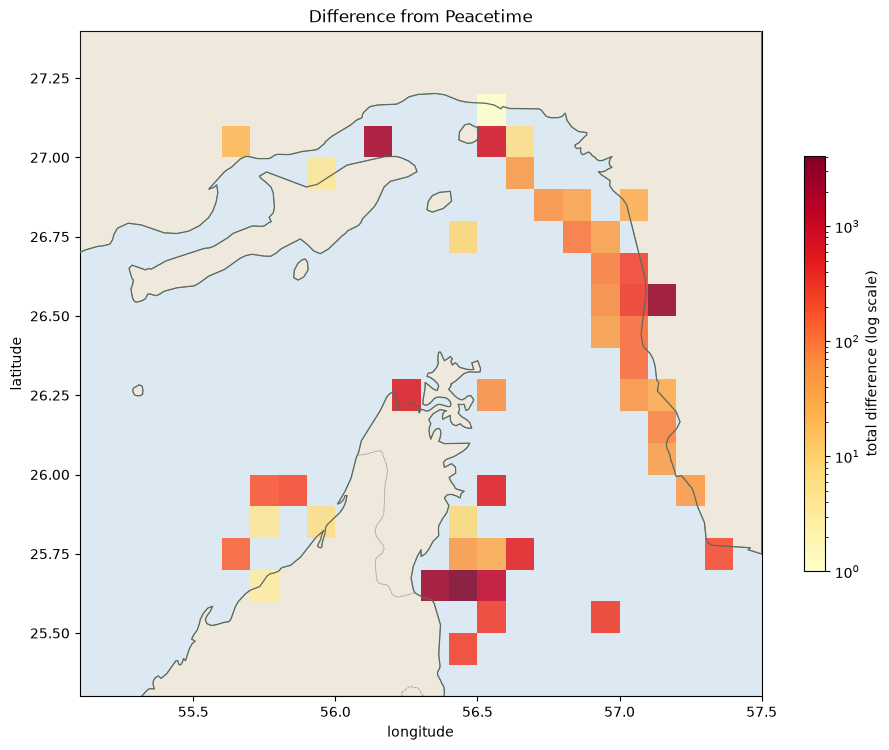

In [2]:
# Compares the presence_90 dataset to the peacetime dataset, and gives a map of the difference in vessel presence, and saves it as an image.
mapping.compare_to_peacetime('presence_hormuz_2026-04-30_2026-07-29.csv', region=mapping.regions.STRAIT_OF_HORMUZ, show=False)

wrote snapshot_hormuz_20260803T050455Z.png


'snapshot_hormuz_20260803T050455Z.png'

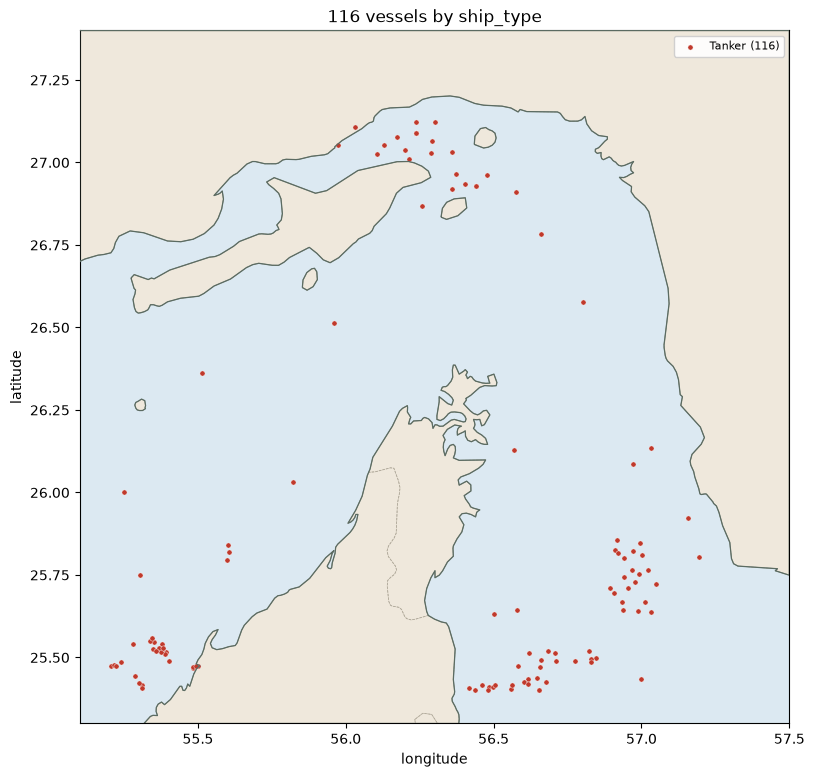

In [6]:
# Creates a map of the Strait of Hormuz from a snapshot of AIS data, with points noting the
# locations of tanker vessels.
mapping.draw('snapshot_hormuz_20260803T050455Z.csv',
             region=mapping.regions.STRAIT_OF_HORMUZ, show=False)

wrote snapshot_hormuz_20260803T050455Z.png


'snapshot_hormuz_20260803T050455Z.png'

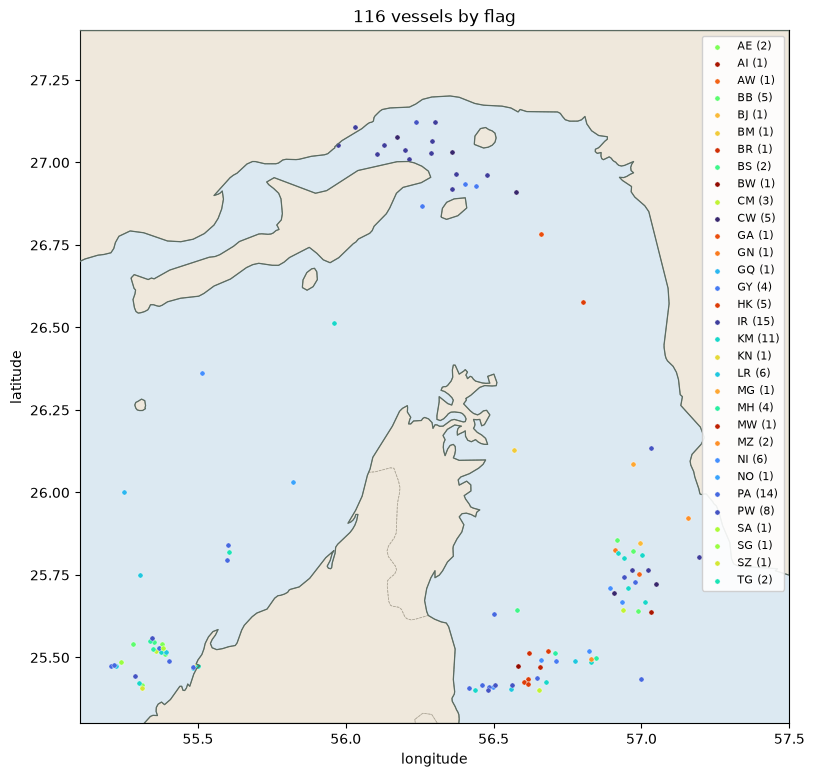

In [4]:
mapping.draw('snapshot_hormuz_20260803T050455Z.csv', color_by='flag', region=mapping.regions.STRAIT_OF_HORMUZ, show=False)

wrote paths_Strait_of_Hormuz_2026-08-17T03-28-20+00-00_to_2026-08-17T04-59-28+00-00.png


'paths_Strait_of_Hormuz_2026-08-17T03-28-20+00-00_to_2026-08-17T04-59-28+00-00.png'

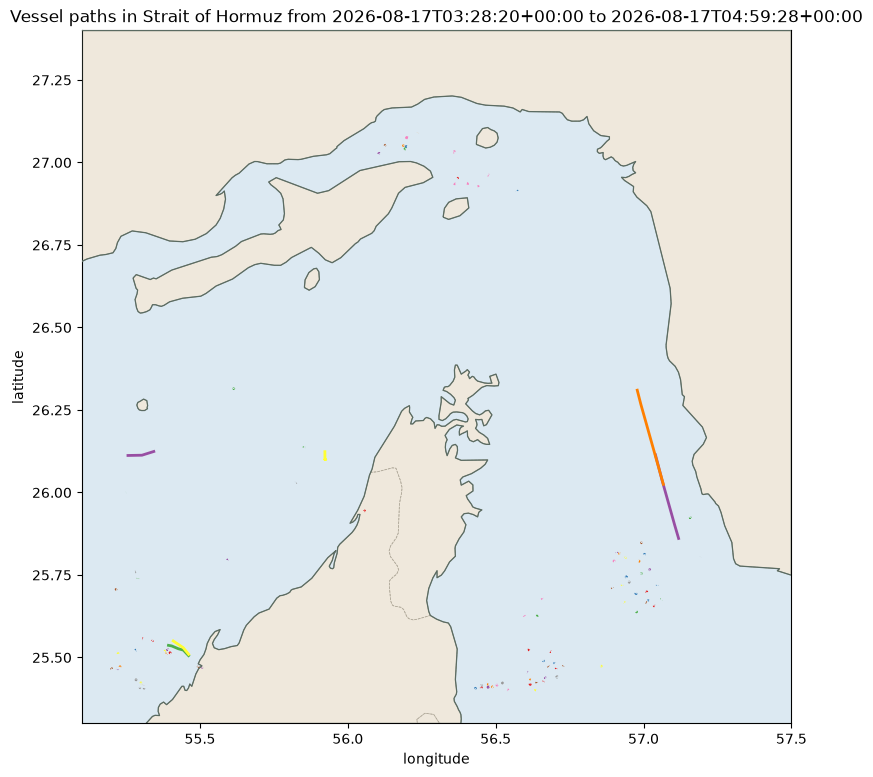

In [1]:
import mapping
csv_paths = [
    'snapshot_hormuz_20260817T032819Z.csv',
    'snapshot_hormuz_20260817T034322Z.csv',
    'snapshot_hormuz_20260817T042918Z.csv',
    'snapshot_hormuz_20260817T044421Z.csv',
    'snapshot_hormuz_20260817T045925Z.csv'
]
mapping.draw_path(csv_paths=csv_paths, region=mapping.regions.STRAIT_OF_HORMUZ, show=False)